In [1]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Success! Project root added: {parent_dir}")
print("Available folders here:", os.listdir(parent_dir))

Success! Project root added: c:\Users\arsal\OneDrive\Desktop\Study Stuff\Projects\AIML\Data Analysis\solar-performance-intelligence
Available folders here: ['.git', '.gitignore', 'data', 'LICENSE', 'README.md', 'reports', 'scripts', 'solar-power-generation-and-energy-consumption-data.zip', 'src']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.settings import PROCESSED_DIR

In [3]:
pd.set_option(
    "display.max_columns",
    None
)

In [4]:
master_df = pd.read_parquet(PROCESSED_DIR / "master_dataset.parquet")
master_df.head(10)

,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,CloudOpacity,Ghi,kWp,Number of panels,lat,Lon,has_capacity_data
0,2,1,2020-01-01 00:15:00,0.0,18.560000,20.300000,9.600000,50.266667,8.680000,152.666667,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
1,2,1,2020-01-01 00:30:00,0.0,18.146667,19.840000,9.340000,50.666667,7.933333,157.533333,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
2,2,1,2020-01-01 00:45:00,0.0,18.140000,19.886667,9.486667,51.000000,8.440000,147.600000,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
3,2,1,2020-01-01 01:00:00,0.0,17.693333,19.540000,9.180000,51.133333,8.680000,151.333333,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
4,2,1,2020-01-01 01:15:00,0.0,17.613333,19.153333,9.053333,51.933333,6.866667,149.333333,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
5,2,1,2020-01-01 01:30:00,0.0,16.906667,18.873333,9.153333,53.266667,9.253333,163.466667,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
6,2,1,2020-01-01 01:45:00,0.0,16.713333,18.460000,8.886667,53.666667,7.666667,167.333333,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
7,2,1,2020-01-01 02:00:00,0.0,16.953333,18.893333,9.133333,53.133333,9.040000,153.400000,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
8,2,1,2020-01-01 02:15:00,0.0,17.060000,19.033333,8.940000,52.000000,9.040000,154.933333,0.0,0.0,NaN,NaN,-36.111209,146.848679,0
9,2,1,2020-01-01 02:30:00,0.0,16.646667,19.040000,8.953333,52.000000,11.080000,146.266667,0.0,0.0,NaN,NaN,-36.111209,146.848679,0


In [5]:
master_df["CampusKey"].value_counts()

CampusKey
1    1720219
3     520702
2     332387
4      79319
5      79319
Name: count, dtype: int64

In [6]:
master_df["kWp"].describe()

count    1.599868e+06
mean     9.532623e+01
std      1.233715e+02
min      2.139000e+01
25%      3.927000e+01
50%      5.115000e+01
75%      7.722000e+01
max      5.398000e+02
Name: kWp, dtype: float64

# Why the PerkWp?
Now we know 100kWp vs 1000 kWp, one might say "oh 1000kwp is better, but in a sense overall output yeah in quantity, but in efficiency?" no, this is because 100 kWp runs on 10kWp panel netwrok which has 1000% efficient, while 1000 kWp is running on 1000 kWp network panel which is 100% efficient, which just means its working as much as it was told, basically one is 10 times more efficient than the other <br>
and this flawed way of looking at raw number led me to believe efficiency will play bigger role than raw number directly

In [7]:
all_df = master_df.copy()
eda_df = master_df.copy()

eda_df = eda_df[eda_df["kWp"].notna()]

eda_df['GenerationPerkWp'] = eda_df["SolarGeneration"] / eda_df["kWp"]

In [8]:
master_df.groupby("CampusKey")["kWp"]\
    .apply(lambda x: x.notna().mean() * 100)

CampusKey
1    93.00374
2     0.00000
3     0.00000
4     0.00000
5     0.00000
Name: kWp, dtype: float64

# Season Mapper
Since we saw a relation between seasons and solar generation, we engineer a new feature Seasson which defines the current season

In [9]:
def season_mapper(month):

    if month in (12, 1, 2):
        return "Summer"
    elif month in (3, 4, 5):
        return "Autumn"
    elif month in (6, 7, 8):
        return "Winter"
    return "Spring"

In [10]:
eda_df["Season"] = (
    eda_df["Timestamp"]
    .dt.month
    .apply(season_mapper)
)
all_df["Season"] = (
    eda_df["Timestamp"]
    .dt.month
    .apply(season_mapper)
)

# Daylight Flag
This is due to the fact we know that the Daylight is the actual reason for the solar panel to generate electricity so having a flag is easier for query and for the model to understand

In [11]:
eda_df["IsDaylight"] = (
    eda_df["Timestamp"]
    .dt.hour
    .between(7, 19)
)
all_df["IsDaylight"] = (
    eda_df["Timestamp"]
    .dt.hour
    .between(7, 19)
)

# Capacity Group
This is where we compare whether bigger systems are actually performing better than smaller ones or not

In [12]:
eda_df["CapacityGroup"] = pd.qcut(
    eda_df["kWp"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Utility"
    ]
)

In [13]:
eda_df['CapacityGroup'].value_counts()

CapacityGroup
Small      447708
Utility    398080
Large      379672
Medium     374408
Name: count, dtype: int64

In [14]:
corr_cols = [
    "GenerationPerkWp",
    "Ghi",
    "CloudOpacity",
    "AirTemperature",
    "RelativeHumidity",
    "WindSpeed"
]

eda_df[corr_cols].corr()

,GenerationPerkWp,Ghi,CloudOpacity,AirTemperature,RelativeHumidity,WindSpeed
GenerationPerkWp,1.000000,0.655150,-0.163756,0.341636,-0.398922,0.216255
Ghi,0.655150,1.000000,-0.292802,0.486528,-0.525819,0.294155
CloudOpacity,-0.163756,-0.292802,1.000000,0.031735,0.120333,0.107492
AirTemperature,0.341636,0.486528,0.031735,1.000000,-0.728524,0.356206
RelativeHumidity,-0.398922,-0.525819,0.120333,-0.728524,1.000000,-0.396340
WindSpeed,0.216255,0.294155,0.107492,0.356206,-0.396340,1.000000


# inference
It can be seen that there is a increasing trend as per seasons, hotter seasons are generating more energy than colder seasons.

<Axes: xlabel='Season'>

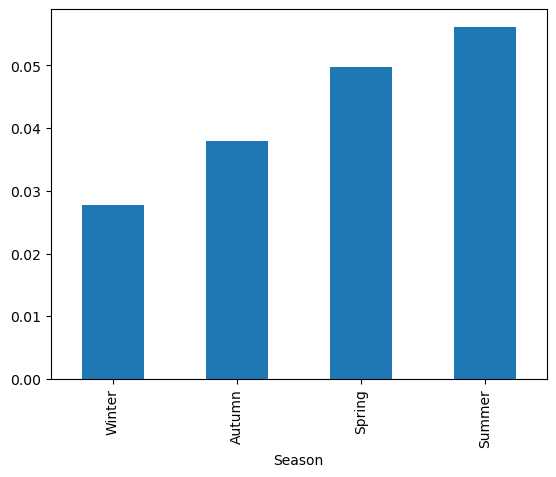

In [15]:
(
    eda_df.groupby("Season")["GenerationPerkWp"]
    .mean()
    .sort_values()
    .plot.bar()
)

C:\Users\arsal\AppData\Local\Temp\ipykernel_13480\889020450.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby('CapacityGroup')["GenerationPerkWp"]


<Axes: xlabel='CapacityGroup'>

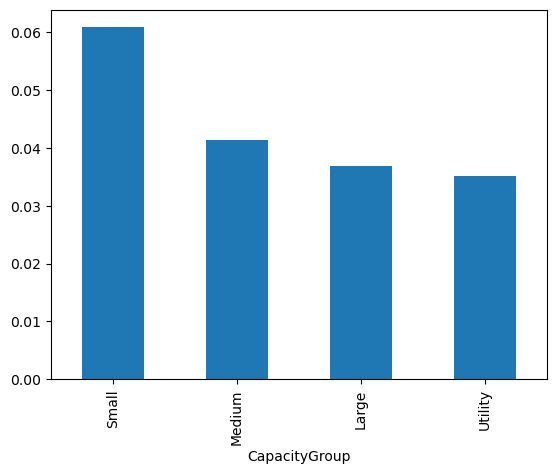

In [16]:
(
    eda_df.groupby('CapacityGroup')["GenerationPerkWp"]
    .mean()
    .plot.bar()
)

# Inference
It can be seen that the smaller Group are actually more efficient than medium or above groups, while medium, large, and utility fairly fall in very close proximity as per SolarGenerationPerkWp

In [17]:
eda_df["CampusKey"].value_counts()

CampusKey
1    1599868
Name: count, dtype: int64

<Axes: xlabel='CampusKey'>

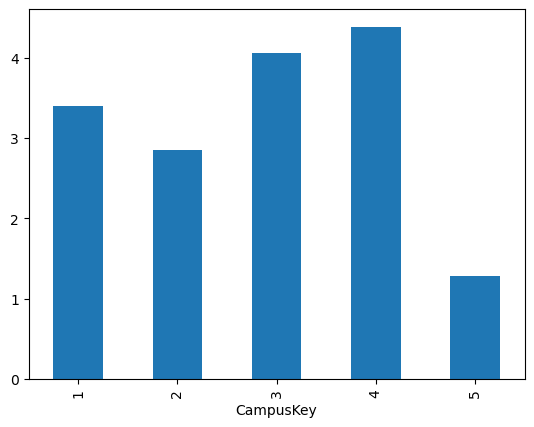

In [18]:
(
    all_df.groupby("CampusKey")["SolarGeneration"]
    .mean()
    .plot.bar()
)

# Further Analysis

In [19]:
df = master_df.copy()

df["Hour"] = df["Timestamp"].dt.hour

df["Month"] = df["Timestamp"].dt.month

df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

df["Quarter"] = df["Timestamp"].dt.quarter

Q. Does Usage Pattern affect prediction?

IsWeekend
0    3.415146
1    3.445998
Name: SolarGeneration, dtype: float64


<Axes: xlabel='IsWeekend', ylabel='SolarGeneration'>

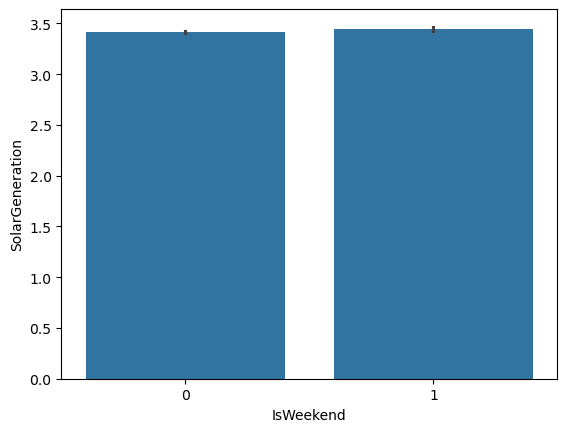

In [20]:
print(df.groupby("IsWeekend")["SolarGeneration"].mean())
sns.barplot(
    data=df,
    x="IsWeekend",
    y="SolarGeneration"
)

Q. Are weekdays different from weekends?

DayOfWeek
0    3.501203
1    3.358636
2    3.464002
3    3.438280
4    3.313737
5    3.375431
6    3.515823
Name: SolarGeneration, dtype: float64


<Axes: xlabel='DayOfWeek', ylabel='SolarGeneration'>

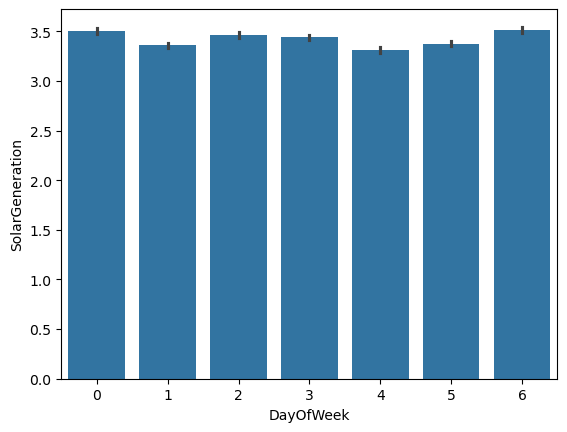

In [21]:
print(df.groupby("DayOfWeek")["SolarGeneration"].mean())
sns.barplot(
    data=df,
    x="DayOfWeek",
    y="SolarGeneration"
)

Quarter
1    4.148633
2    2.332570
3    2.764876
4    4.009582
Name: SolarGeneration, dtype: float64


<Axes: xlabel='Quarter', ylabel='SolarGeneration'>

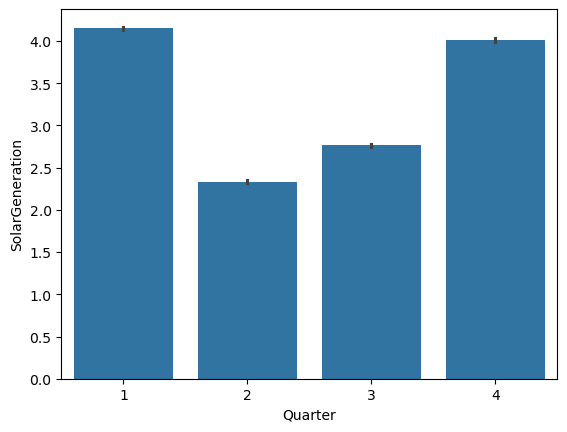

In [22]:
print(df.groupby("Quarter")["SolarGeneration"].mean())
sns.barplot(
    data=df,
    x="Quarter",
    y="SolarGeneration"
)

Do all campuses behave similarly?

Does Campus 5 have a strange seasonal profile?

<Axes: xlabel='Month', ylabel='CampusKey'>

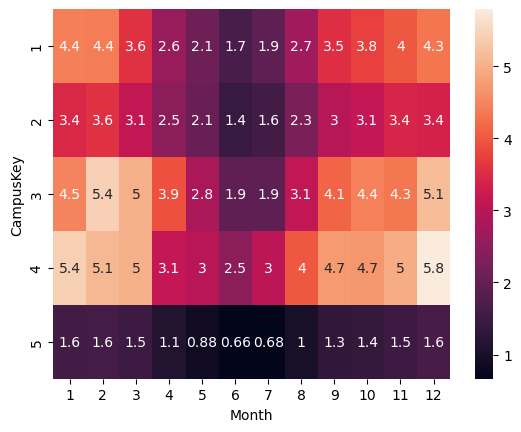

In [23]:
pivot = (
    df.pivot_table(
        values="SolarGeneration",
        index="CampusKey",
        columns="Month",
        aggfunc="mean"
    )
)

sns.heatmap(
    pivot,
    annot=True
)

Weather Aggregation <br>

In [24]:
weather_df = master_df.copy()

weather_df = weather_df[
    weather_df["SolarGeneration"] > 0
]

C:\Users\arsal\AppData\Local\Temp\ipykernel_13480\1253128859.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_df.groupby(pd.cut(weather_df[col], bins=10))["SolarGeneration"]
C:\Users\arsal\AppData\Local\Temp\ipykernel_13480\1253128859.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_df.groupby(pd.cut(weather_df[col], bins=10))["SolarGeneration"]
C:\Users\arsal\AppData\Local\Temp\ipykernel_13480\1253128859.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed

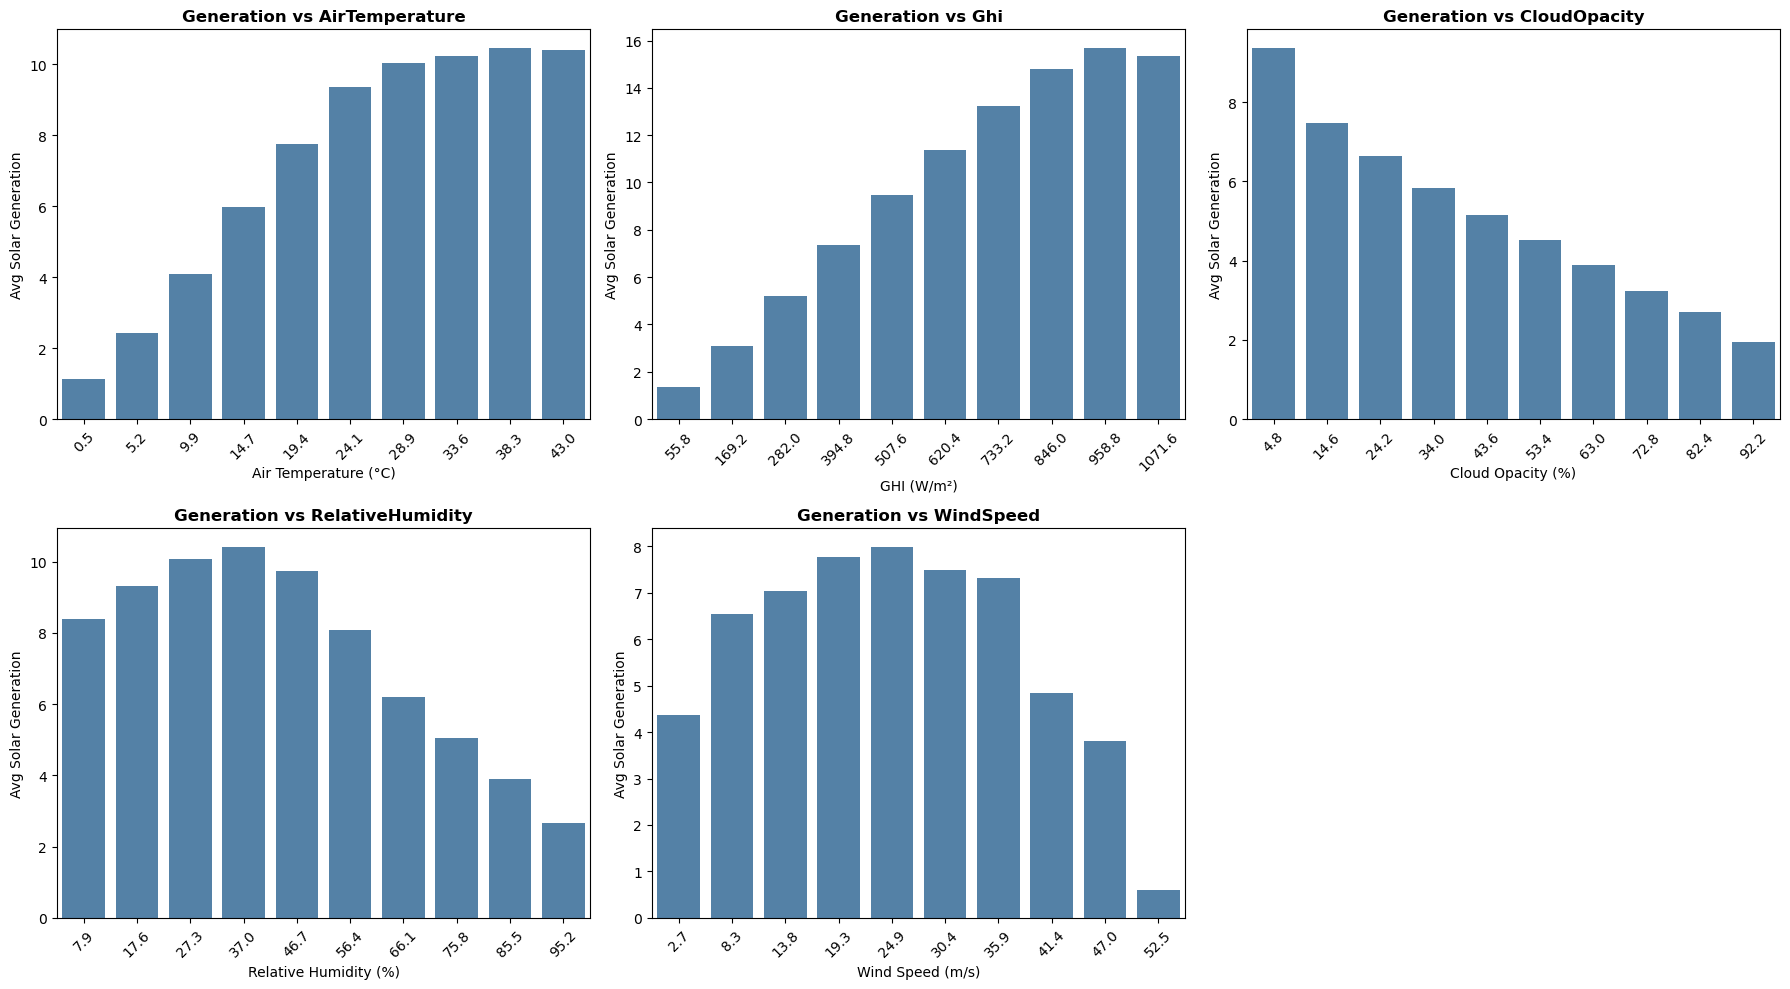

In [25]:
features = ["AirTemperature", "Ghi", "CloudOpacity", "RelativeHumidity", "WindSpeed"]
feature_labels = [
    "Air Temperature (°C)",
    "GHI (W/m²)",
    "Cloud Opacity (%)",
    "Relative Humidity (%)",
    "Wind Speed (m/s)",
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() 

for i, col in enumerate(features):
    if col in weather_df.columns:
        binned_data = (
            weather_df.groupby(pd.cut(weather_df[col], bins=10))["SolarGeneration"]
            .mean()
            .reset_index()
        )

        binned_data[col] = binned_data[col].apply(lambda x: round(x.mid, 1))

        sns.barplot(
            data=binned_data,
            x=col,
            y="SolarGeneration",
            color="steelblue",
            ax=axes[i],
        )

        axes[i].set_title(f"Generation vs {col}", fontsize=12, fontweight="bold")
        axes[i].set_xlabel(feature_labels[i], fontsize=10)
        axes[i].set_ylabel("Avg Solar Generation", fontsize=10)
        axes[i].tick_params(axis="x", rotation=45)  

axes[5].set_visible(False)

plt.tight_layout()
plt.show()


In [26]:
master_df["CloudOpacity"].describe()

count    2.699161e+06
mean     2.618417e+01
std      2.738322e+01
min      0.000000e+00
25%      7.500000e-02
50%      1.730000e+01
75%      4.710000e+01
max      9.700000e+01
Name: CloudOpacity, dtype: float64

# Some Hypothesis Testing

In [27]:
master_df["Ghi"].describe()

count    2.699161e+06
mean     1.921760e+02
std      2.767361e+02
min      0.000000e+00
25%      0.000000e+00
50%      1.950000e+01
75%      3.190000e+02
max      1.128000e+03
Name: Ghi, dtype: float64

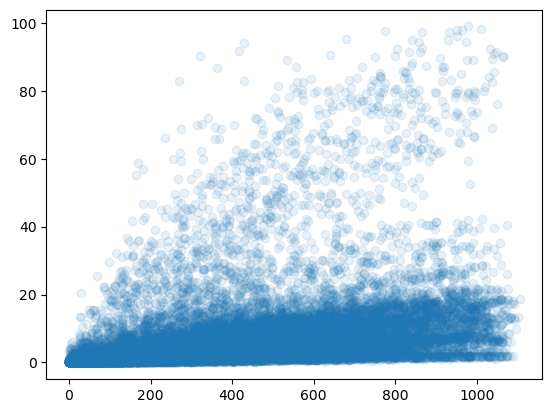

In [28]:
sample = master_df.sample(
    50000,
    random_state=42
)

plt.scatter(
    sample["Ghi"],
    sample["SolarGeneration"],
    alpha=0.1
)

In [29]:
master_df["Hour"] = master_df["Timestamp"].dt.hour

In [30]:
x = master_df[
    (master_df["Hour"] >= 8)
    &
    (master_df["Hour"] <= 18)
    &
    (master_df["SolarGeneration"] > 0)
]

x[[
    "SolarGeneration",
    "Ghi"
]].corr()

,SolarGeneration,Ghi
SolarGeneration,1.000000,0.376339
Ghi,0.376339,1.000000


In [31]:
site = 1

tmp = master_df[
    master_df["SiteKey"] == site
].copy()

In [32]:
day = "2021-01-15"

x = tmp[
    tmp["Timestamp"].dt.date
    ==
    pd.to_datetime(day).date()
]

In [33]:
x.columns

Index(['CampusKey', 'SiteKey', 'Timestamp', 'SolarGeneration',
       'ApparentTemperature', 'AirTemperature', 'DewPointTemperature',
       'RelativeHumidity', 'WindSpeed', 'WindDirection', 'CloudOpacity', 'Ghi',
       'kWp', 'Number of panels', 'lat', 'Lon', 'has_capacity_data', 'Hour'],
      dtype='object')

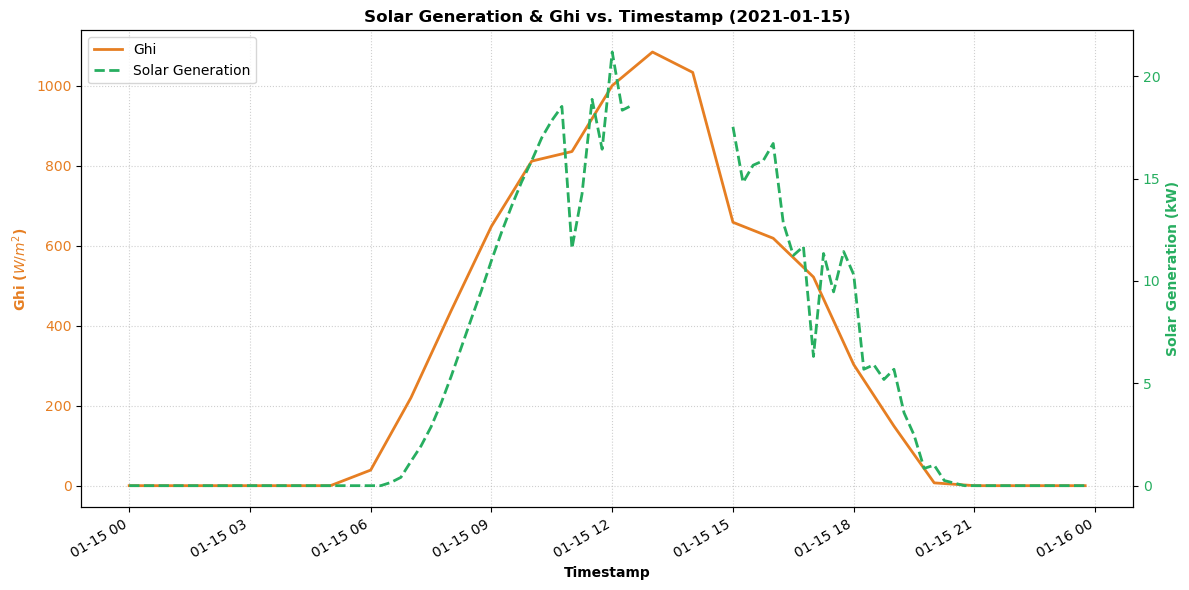

In [34]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color_ghi = "#e67e22" 
ax1.set_xlabel("Timestamp", fontweight="bold")
ax1.set_ylabel("Ghi ($W/m^2$)", color=color_ghi, fontweight="bold")
line1 = ax1.plot(
    x["Timestamp"], x["Ghi"], color=color_ghi, linewidth=2, label="Ghi"
)
ax1.tick_params(axis="y", labelcolor=color_ghi)
ax1.grid(True, linestyle=":", alpha=0.6)

ax2 = ax1.twinx()
color_gen = "#27ae60"  # Green
ax2.set_ylabel("Solar Generation (kW)", color=color_gen, fontweight="bold")
line2 = ax2.plot(
    x["Timestamp"],
    x["SolarGeneration"],
    color=color_gen,
    linewidth=2,
    linestyle="--",
    label="Solar Generation",
)
ax2.tick_params(axis="y", labelcolor=color_gen)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title(f"Solar Generation & Ghi vs. Timestamp ({day})", fontweight="bold")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [35]:
tmp = master_df.copy()
tmp["Ghi_Shifted"] = (
    tmp.groupby("CampusKey")["Ghi"]
    .shift(10)
)

In [36]:
site = 1

tmpx = master_df[
    master_df["SiteKey"] == site
].copy()

In [37]:
tmp = tmpx.copy()
tmp["Ghi_Shifted"] = (
    tmp.groupby("CampusKey")["Ghi"]
    .shift(10)
)

In [38]:
day = "2021-01-15"

z = tmp[
    tmp["Timestamp"].dt.date
    ==
    pd.to_datetime(day).date()
]

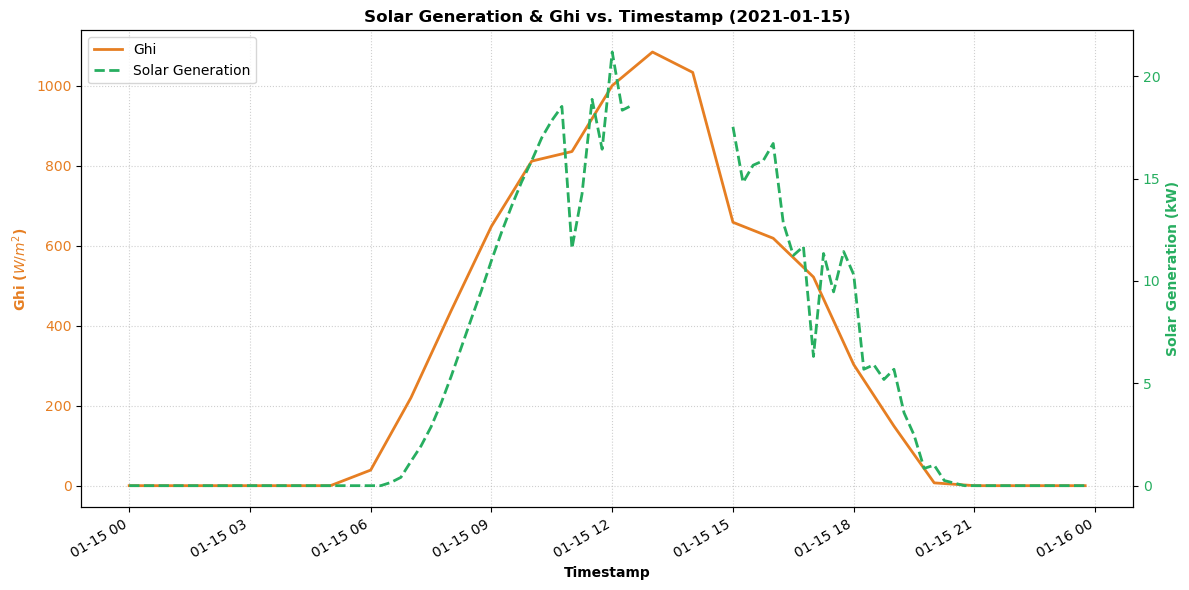

In [39]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color_ghi = "#e67e22" 
ax1.set_xlabel("Timestamp", fontweight="bold")
ax1.set_ylabel("Ghi ($W/m^2$)", color=color_ghi, fontweight="bold")
line1 = ax1.plot(
    z["Timestamp"], z["Ghi"], color=color_ghi, linewidth=2, label="Ghi"
)
ax1.tick_params(axis="y", labelcolor=color_ghi)
ax1.grid(True, linestyle=":", alpha=0.6)

ax2 = ax1.twinx()
color_gen = "#27ae60"  # Green
ax2.set_ylabel("Solar Generation (kW)", color=color_gen, fontweight="bold")
line2 = ax2.plot(
    z["Timestamp"],
    z["SolarGeneration"],
    color=color_gen,
    linewidth=2,
    linestyle="--",
    label="Solar Generation",
)
ax2.tick_params(axis="y", labelcolor=color_gen)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.title(f"Solar Generation & Ghi vs. Timestamp ({day})", fontweight="bold")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()